In [2]:
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
import torch
import torch.nn as nn

In [59]:
Nx= 500
cfl= 0.1
tmax = 2 # time 0 ~ 1
viscosity_coeff = (0.01/math.pi)

x = np.linspace(-1,1, Nx)

#t = 0  , I.C
u = -1*np.sin(math.pi * x)+0.5*np.sin(math.pi * x*4)
dx = abs(x[1]-x[0])

dt = cfl * dx / np.max(np.abs(u))

nt = int(tmax/ dt) #+ 1

uf = np.zeros((nt,Nx))
uf[0, :] = u

print(nt)
print(dt)
print(nt * dt, tmax )

7145
0.0002799017806523905
1.99989822276133 2


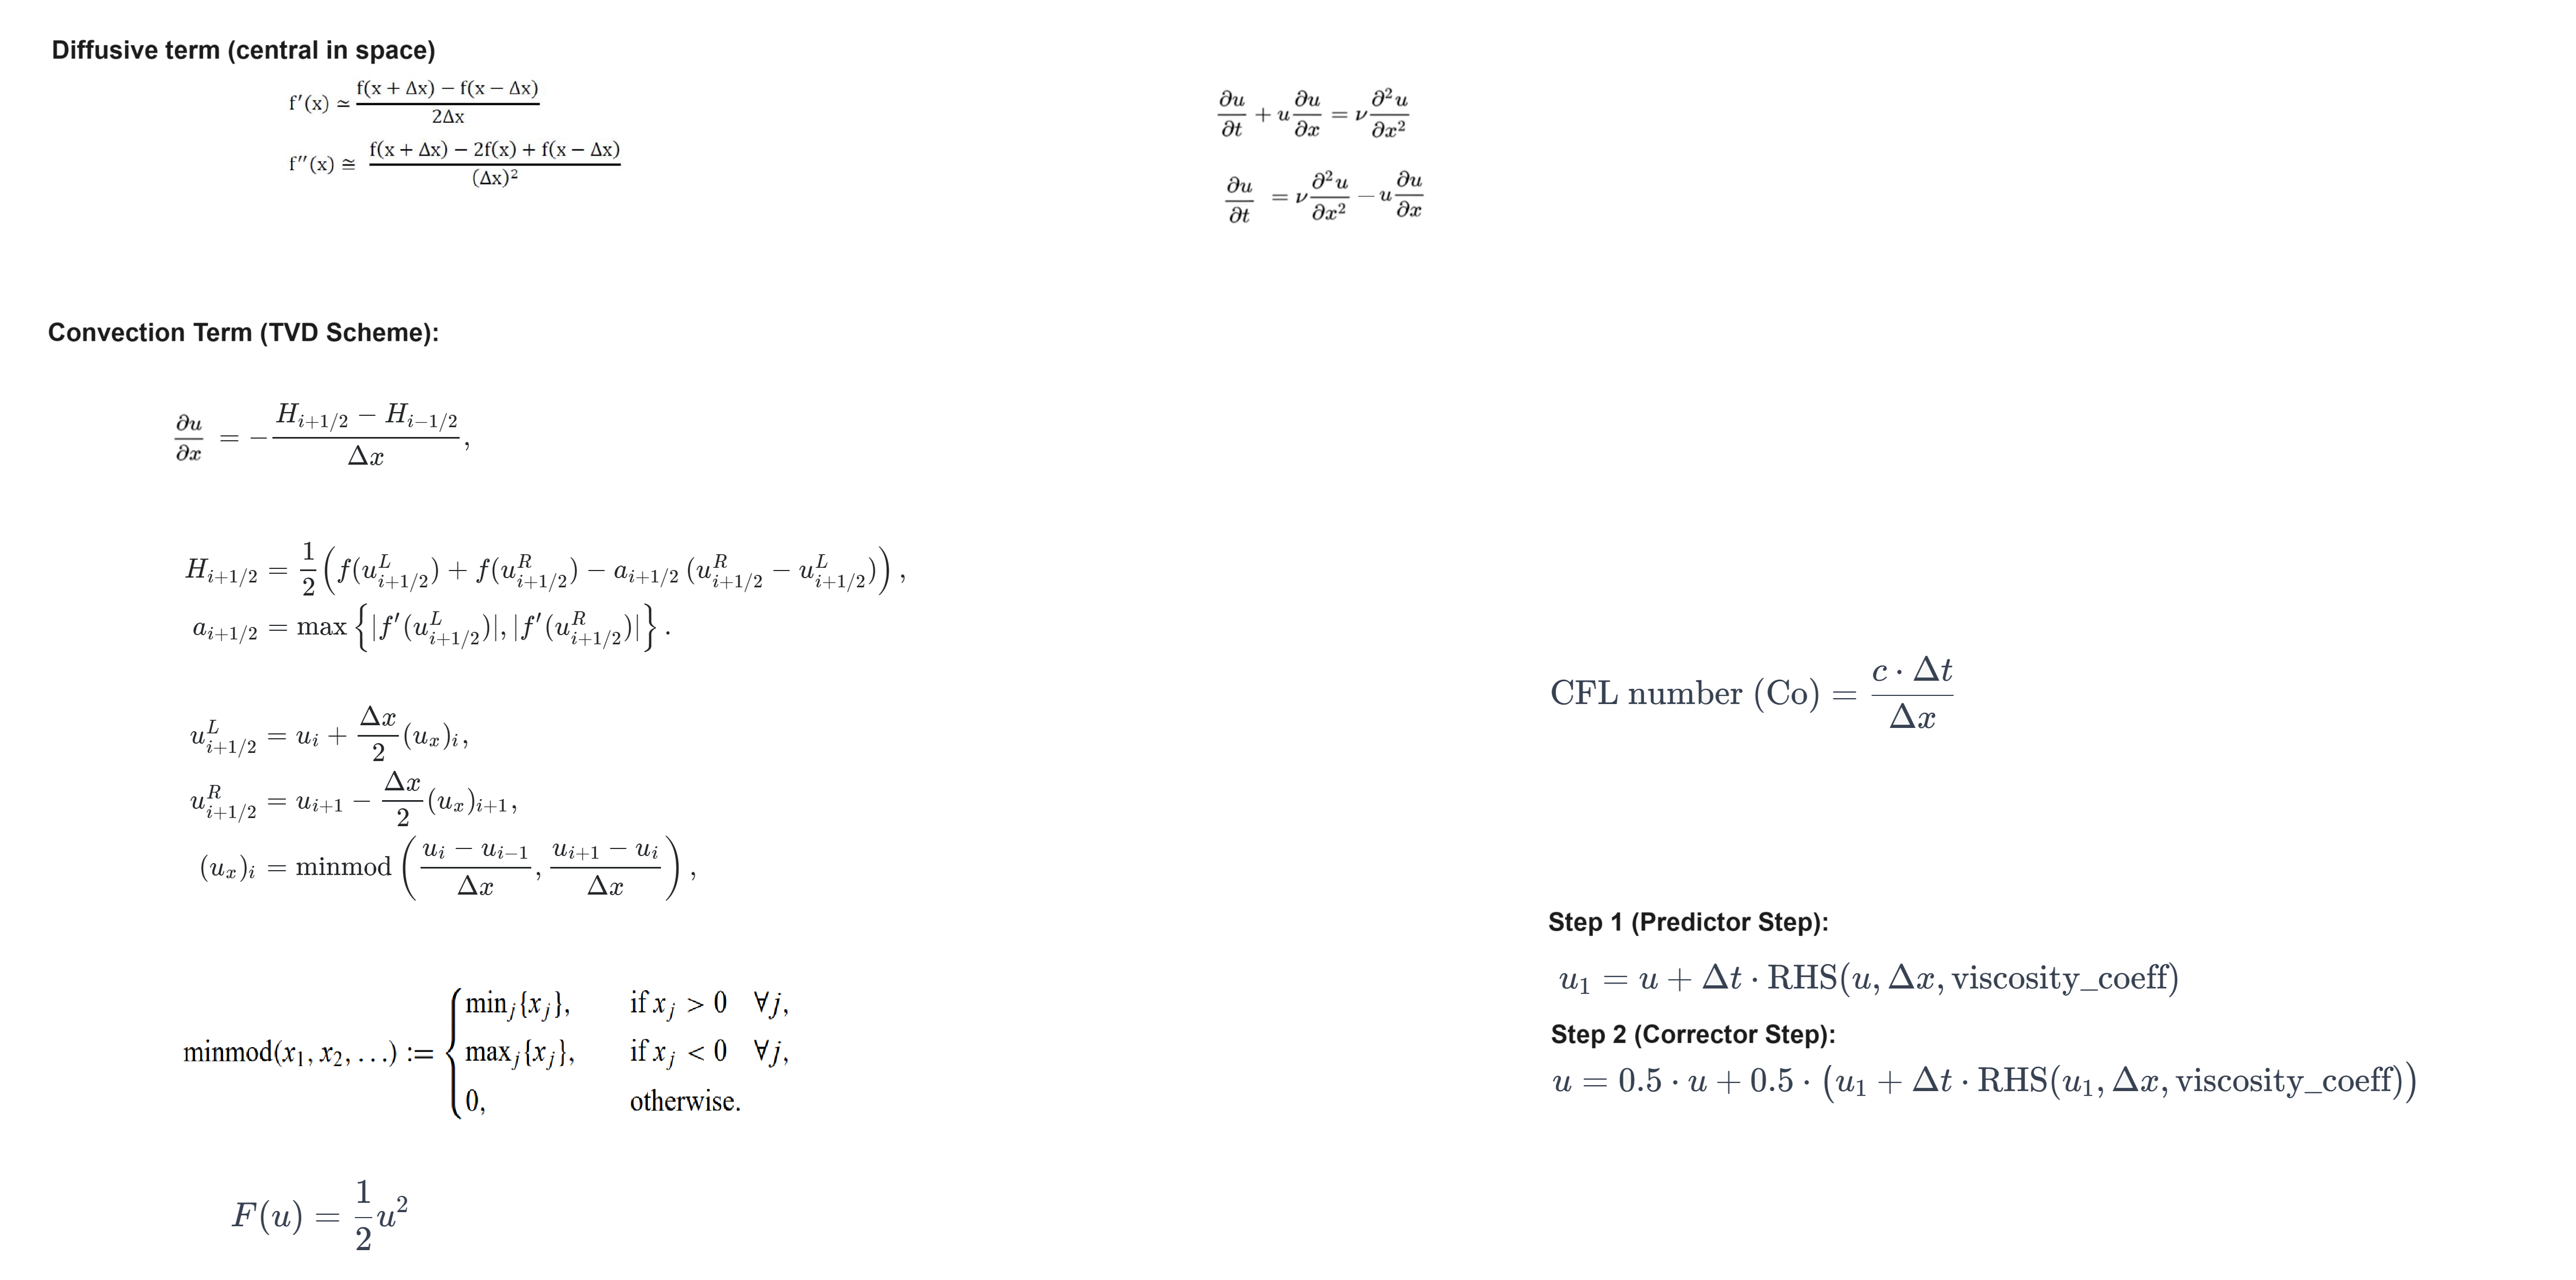

In [60]:
def f(u):
    y = 0.5 * u**2
    yp = u
    return y, yp

In [61]:
def minmod(a,b):
    return 0.5 * (np.sign(a)+ np.sign(b)) * np.minimum(np.abs(a), np.abs(b))

In [62]:
def RHS(u, dx, viscosity_coeff):
    # 1. Compute the diffusion term (central difference)
    diffusion_term = viscosity_coeff * (np.roll(u, -1) - 2 * u + np.roll(u, 1)) / dx**2

    # 2. Compute limited slope (minmod)
    du_forward  = (np.roll(u, -1) - u) / dx
    du_backward = (u - np.roll(u, 1)) / dx
    ux = minmod(du_backward, du_forward)

    # 3. Reconstruct left and right states at i+1/2
    uL = u + 0.5 * dx * ux       # left-biased at i+1/2
    uR = np.roll(u, -1) - 0.5 * dx * np.roll(ux, -1)  # right-biased at i+1/2

    # 4. Compute physical flux and wave speed
    fL, fpL = f(uL)
    fR, fpR = f(uR)
    a = np.maximum(np.abs(fpL), np.abs(fpR))

    # 5. Compute numerical flux H at i+1/2
    H = 0.5 * (fL + fR - a * (uR - uL))

    # 6. Compute convection term: - (H_{i+1/2} - H_{i-1/2}) / dx
    conv_term = -(H - np.roll(H, 1)) / dx

    return conv_term + diffusion_term

In [63]:
for i in range(1, nt):
    u1 = u + dt * RHS(u,dx,viscosity_coeff)
    u = 0.5 * u + 0.5 * (u1 + dt * RHS(u1, dx,viscosity_coeff))
    uf[i, :] = u

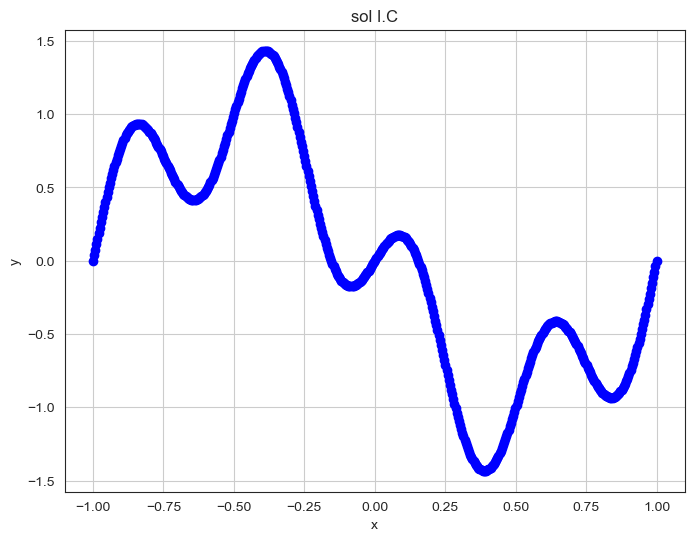

In [64]:
plt.figure(figsize=(8,6))
plt.plot(x, uf[0, :], '-o', color = 'b')
plt.title("sol I.C")
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

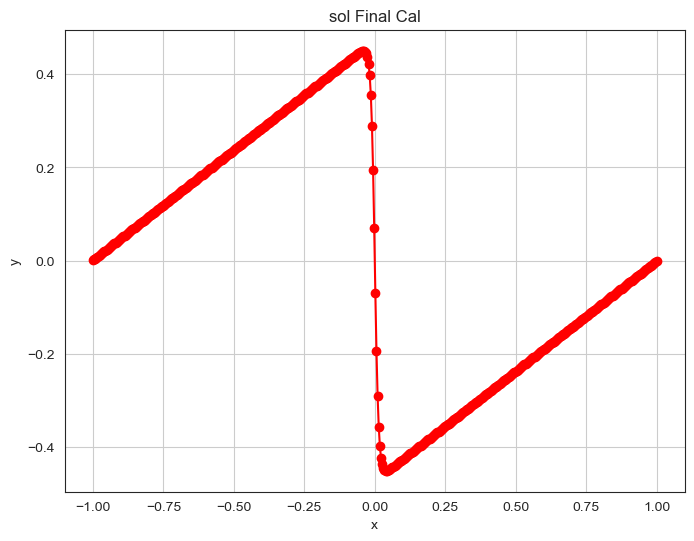

In [65]:
plt.figure(figsize=(8,6))
plt.plot(x, uf[-1, :], '-o', color = 'r')
plt.title("sol Final Cal")
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

<Axes: >

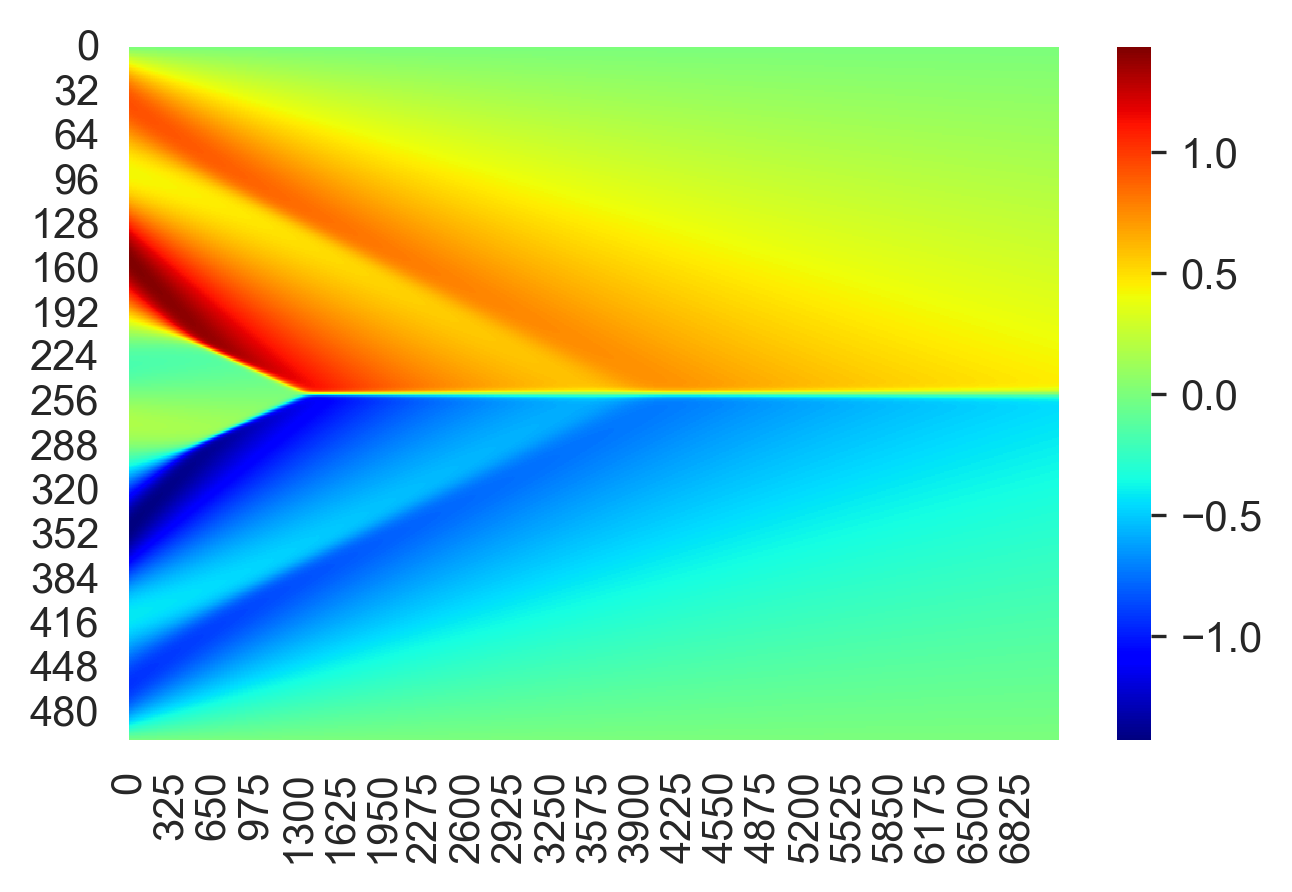

In [66]:
sns.set_style("white")
plt.figure(figsize=(5,3), dpi = 300)
sns.heatmap(uf.T, cmap = 'jet')

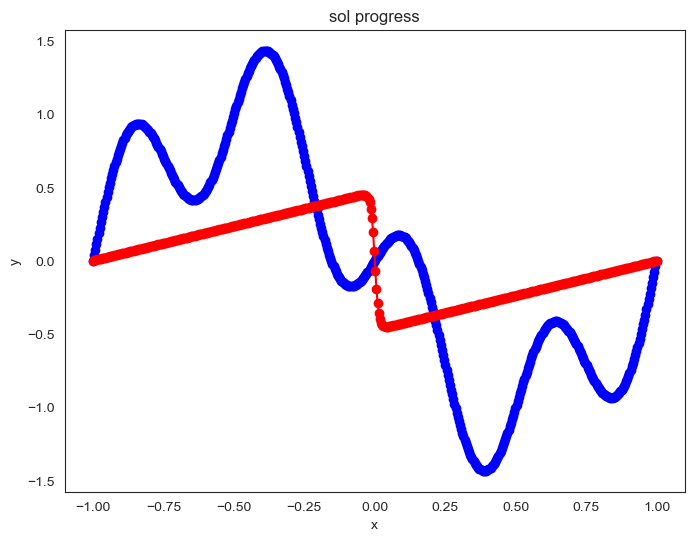

In [67]:
plt.figure(figsize=(8,6))
plt.plot(x, uf[0,:], '-o', color = 'b')
plt.plot(x, uf[-1,:], '-o', color = 'r')
plt.title("sol progress")
plt.xlabel('x')
plt.ylabel('y')
#plt.grid(True)
plt.show()

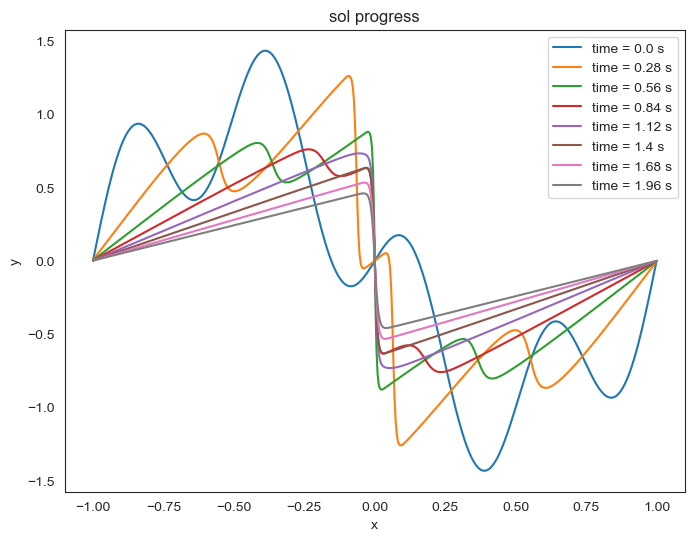

In [81]:
plt.figure(figsize=(8,6))
for time in range(0, nt, 1000):
    TIME = time*dt
    plt.plot(x, uf[time, :], label=f'time = {round(TIME, 2)} s')
    
plt.title("sol progress")
plt.xlabel('x')
plt.ylabel('y')
#plt.grid(True)
plt.legend()
plt.show()

In [96]:
class NN(nn.Module):
    def __init__(self):
        super(NN, self).__init__()
        self.net = torch.nn.Sequential(
            nn.Linear(2,20),
            nn.Tanh(),
            nn.Linear(20,30),
            nn.Tanh(),
            nn.Linear(30,30),
            nn.Tanh(),
            nn.Linear(30,20),
            nn.Tanh(),
            nn.Linear(20,20),
            nn.Tanh(),
            nn.Linear(20,1)
        )
    
    def forward(self, x):
        out = self.net(x)
        return out

In [99]:
class Net:
    def __init__(self):
        device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
        
        self.model = NN().to(device)
        
        # comp. domain 
        self.h = 0.04
        self.k = 0.04
        x = torch.arange(-1,1+self.h, self.h)
        t = torch.arange(0,2+self.k, self.k)
        
        self.X = torch.stack(torch.meshgrid(x,t)).reshape(2,-1).T
        
        # train data
        bc1 = torch.stack(torch.meshgrid(x[0],t)).reshape(2,-1).T
        bc2 = torch.stack(torch.meshgrid(x[-1],t)).reshape(2,-1).T
        ic  = torch.stack(torch.meshgrid(x,t[0])).reshape(2,-1).T
        self.X_train = torch.cat([bc1, bc2, ic])
        
        y_bc1 = torch.zeros(len(bc1))
        y_bc2 = torch.zeros(len(bc2))
        y_ic  = -torch.sin(math.pi * ic[:,0])+0.5*torch.sin(math.pi * ic[:,0]*4)
        #y_ic  = -torch.sin(math.pi * ic[:,0])
        print(y_ic)
        
        self.y_train = torch.cat([y_bc1, y_bc2, y_ic])
        self.y_train = self.y_train.unsqueeze(1)
        
        self.X = self.X.to(device)
        self.y_train = self.y_train.to(device)
        self.X_train = self.X_train.to(device)
        self.X.requires_grad = True
        
        # optimizer setting
        self.adam =  torch.optim.Adam(self.model.parameters())
        #Limited-memory Broyden-Fletcher-Goldfarb-Shanno (L-BFGS)
        self.optimizer = torch.optim.LBFGS(
            self.model.parameters(),
            lr=1.0,
            max_iter = 50000,
            max_eval = 50000,
            history_size = 50,
            tolerance_grad = 1e-7,
            tolerance_change = 1.0* np.finfo(float).eps,
            line_search_fn ="strong_wolfe"
        )
        
        self.criterion = torch.nn.MSELoss()
        self.iter = 1
    
    def loss_func(self):
        self.adam.zero_grad()
        self.optimizer.zero_grad()
        
        y_pred = self.model(self.X_train)
        loss_data = self.criterion(y_pred,self.y_train)
        
        u = self.model(self.X)
        
        du_dX = torch.autograd.grad(
            u,
            self.X,
            grad_outputs = torch.ones_like(u),
            create_graph = True,
            retain_graph = True
        )[0]
        
        #print(du_dX)
        #print("xxxxxxxxxxxxxxxxxxxxxxxxx")
        #print(du_dX[0])
        
        du_dt = du_dX[:,1]
        du_dx = du_dX[:,0]
        
        du_dXX = torch.autograd.grad(
            du_dX,
            self.X,
            grad_outputs = torch.ones_like(du_dX),
            create_graph = True,
            retain_graph = True
        )[0]
        
        du_dxx = du_dXX[:,0]
        
        loss_pde = self.criterion(du_dt + 1*u.squeeze()*du_dx , (0.01/math.pi) * du_dxx)
        
        loss = loss_pde + loss_data
        loss.backward()
        
        if self.iter % 100 == 0:
            print(self.iter, loss.item())
        self.iter = self.iter+1
        
        return loss
    
    def train(self):
        self.model.train()
        for i in range(1000):
            self.adam.step(self.loss_func)
        self.optimizer.step(self.loss_func)
    
    def eval_(self):
        self.model.eval()

In [100]:
# training
net = Net()
net.train()
net.model.eval()

tensor([-2.6227e-07,  3.6621e-01,  6.7085e-01,  8.6714e-01,  9.3417e-01,
         8.8168e-01,  7.4721e-01,  5.8645e-01,  4.5907e-01,  4.1368e-01,
         4.7553e-01,  6.4001e-01,  8.7368e-01,  1.1224e+00,  1.3246e+00,
         1.4266e+00,  1.3960e+00,  1.2296e+00,  9.5458e-01,  6.2188e-01,
         2.9389e-01,  2.9340e-02, -1.3089e-01, -1.7347e-01, -1.1554e-01,
         0.0000e+00,  1.1554e-01,  1.7347e-01,  1.3089e-01, -2.9340e-02,
        -2.9389e-01, -6.2188e-01, -9.5458e-01, -1.2296e+00, -1.3960e+00,
        -1.4266e+00, -1.3246e+00, -1.1224e+00, -8.7368e-01, -6.4001e-01,
        -4.7553e-01, -4.1368e-01, -4.5907e-01, -5.8645e-01, -7.4721e-01,
        -8.8168e-01, -9.3417e-01, -8.6714e-01, -6.7085e-01, -3.6621e-01,
         2.6227e-07])
100 0.16699093580245972
200 0.10661846399307251
300 0.0998544842004776
400 0.09235194325447083
500 0.08478938043117523
600 0.07881519198417664
700 0.06134384125471115
800 0.05444248393177986
900 0.05237467959523201
1000 0.050838276743888855
1100 0.

NN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=20, bias=True)
    (1): Tanh()
    (2): Linear(in_features=20, out_features=30, bias=True)
    (3): Tanh()
    (4): Linear(in_features=30, out_features=30, bias=True)
    (5): Tanh()
    (6): Linear(in_features=30, out_features=20, bias=True)
    (7): Tanh()
    (8): Linear(in_features=20, out_features=20, bias=True)
    (9): Tanh()
    (10): Linear(in_features=20, out_features=1, bias=True)
  )
)

In [101]:
h = 0.004
k = 0.004

x = torch.arange(-1,1,h)
t = torch.arange(0,2,k)

X= torch.stack(torch.meshgrid(x,t)).reshape(2,-1).T
X= X.to(net.X.device)

model = net.model
model.eval()
with torch.no_grad():
    y_pred = model(X)
    y_pred = y_pred.reshape(len(x),len(t)).cpu().numpy()

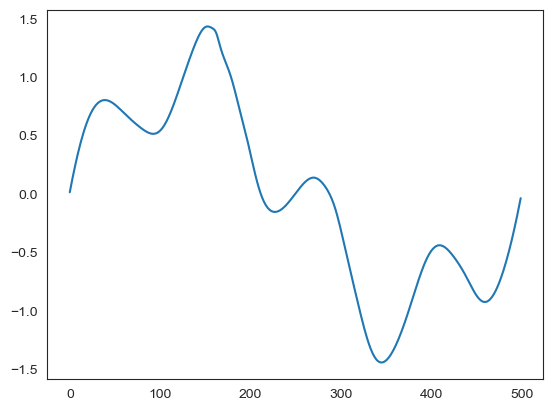

In [102]:
#I.C
plt.plot(y_pred[:,0])

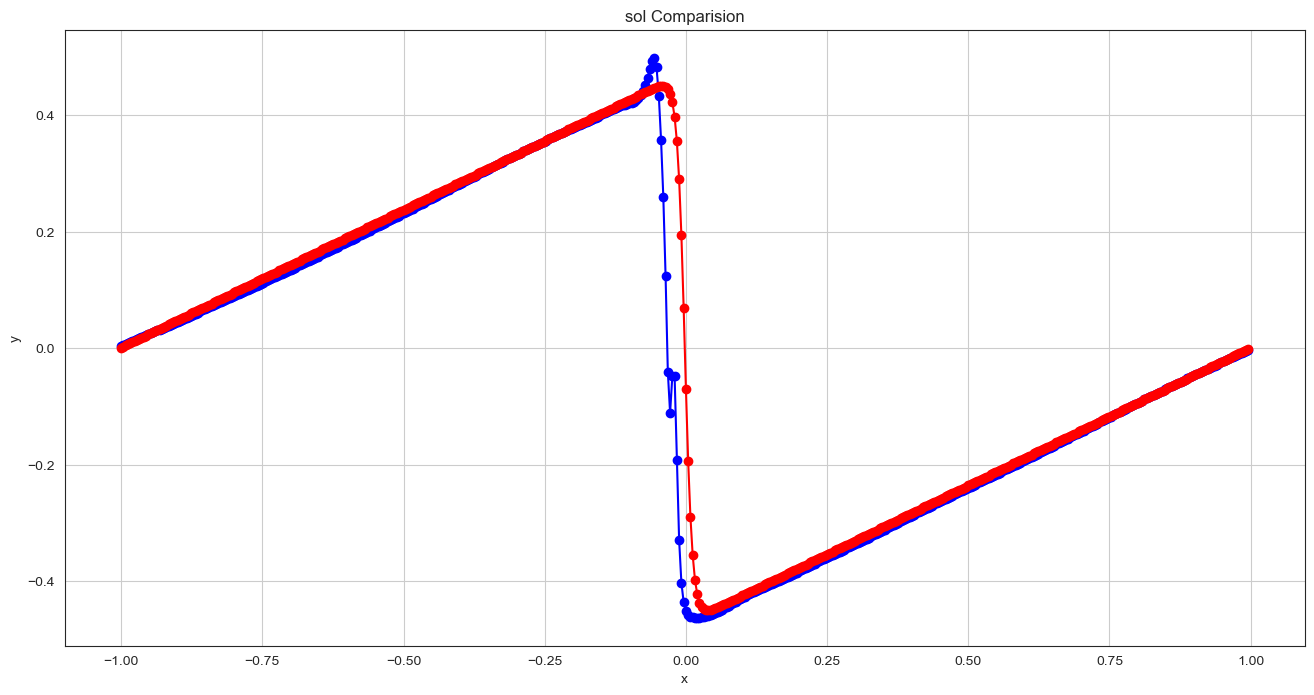

In [104]:
plt.figure(figsize=(16,8))
plt.plot(x, y_pred[:,-1], '-o', color = 'b') #PINNs
plt.plot(x, uf[-1], '-o', color = 'r') #TVD
plt.title("sol Comparision")
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()